In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [125]:
races = pd.read_csv('Race_Schedule.csv')
drivers = pd.read_csv('Driver_Details.csv')
results = pd.read_csv('Race_results.csv')
teams = pd.read_csv('Team_Details.csv')

In [126]:
df = (results.merge(teams[['constructorId' , 'name']], on="constructorId")
     .merge(drivers[['driverId' , 'forename', 'surname']], on="driverId")
     .merge(races[['raceId' , 'name']], on="raceId")
      .merge(races[['raceId' , 'year']], on="raceId"))


In [127]:
df['driver_name'] = df['forename'] + ' ' + df['surname']

In [128]:
df = df.drop(columns=['forename', 'surname'])

In [129]:
df = df.rename(columns={'year': 'race_year', 'name_x': 'team', 'name_y':'race_name'})

In [130]:
df.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,team,race_name,race_year,driver_name
0,1,18,1,1,22,1,1,1,1,10.0,...,5690616,39,2,1:27.452,218.300,1,McLaren,Australian Grand Prix,2008,Lewis Hamilton
1,2,18,2,2,3,5,2,2,2,8.0,...,5696094,41,3,1:27.739,217.586,1,BMW Sauber,Australian Grand Prix,2008,Nick Heidfeld
2,3,18,3,3,7,7,3,3,3,6.0,...,5698779,41,5,1:28.090,216.719,1,Williams,Australian Grand Prix,2008,Nico Rosberg
3,4,18,4,4,5,11,4,4,4,5.0,...,5707797,58,7,1:28.603,215.464,1,Renault,Australian Grand Prix,2008,Fernando Alonso
4,5,18,5,1,23,3,5,5,5,4.0,...,5708630,43,1,1:27.418,218.385,1,McLaren,Australian Grand Prix,2008,Heikki Kovalainen


In [131]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26519 entries, 0 to 26518
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resultId         26519 non-null  int64  
 1   raceId           26519 non-null  int64  
 2   driverId         26519 non-null  int64  
 3   constructorId    26519 non-null  int64  
 4   number           26519 non-null  str    
 5   grid             26519 non-null  int64  
 6   position         26519 non-null  str    
 7   positionText     26519 non-null  str    
 8   positionOrder    26519 non-null  int64  
 9   points           26519 non-null  float64
 10  laps             26519 non-null  int64  
 11  time             26519 non-null  str    
 12  milliseconds     26519 non-null  str    
 13  fastestLap       26519 non-null  str    
 14  rank             26519 non-null  str    
 15  fastestLapTime   26519 non-null  str    
 16  fastestLapSpeed  26519 non-null  str    
 17  statusId         26519 

In [132]:
wins = df[df['positionOrder'] == 1].copy()

In [133]:
wins_counts = wins.groupby(['race_year', 'driver_name']).size().reset_index(name='win_count')

In [134]:
top_winners = wins_counts.sort_values(['race_year', 'win_count'], ascending=[True,False]).drop_duplicates('race_year')

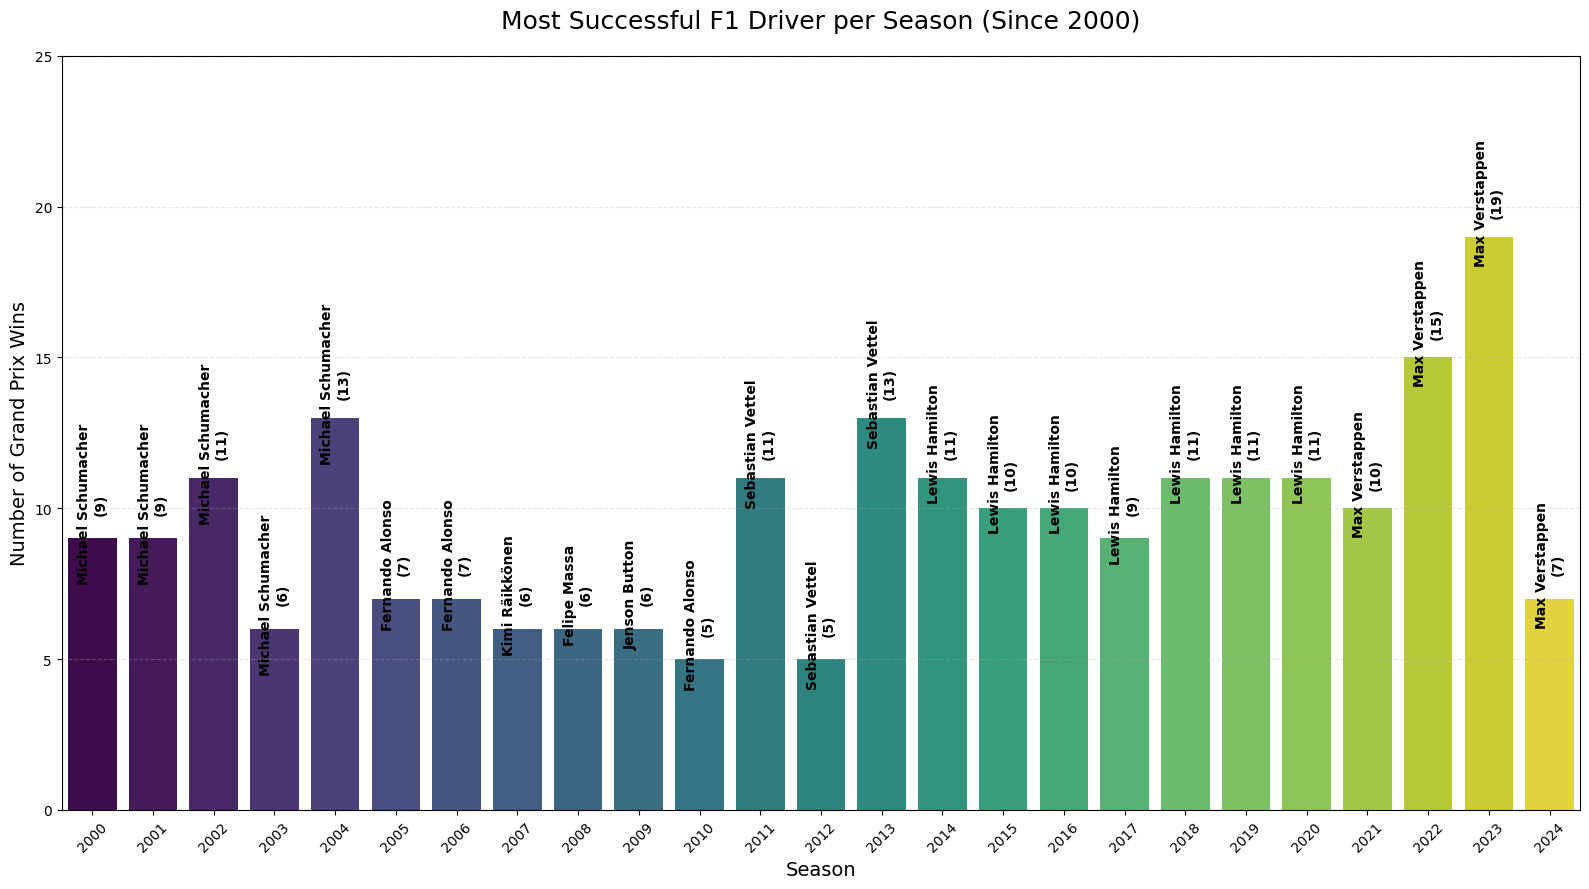

In [142]:
plt.figure(figsize=(16, 9))

plot_data = top_winners[top_winners['race_year'] >= 2000]

ax = sns.barplot(data=plot_data, x='race_year', y='win_count', hue='race_year', palette='viridis', legend=False)

# Add the driver names as labels on top of the bars
for i, p in enumerate(ax.patches):
    driver = plot_data.iloc[i]['driver_name']
    wins_num = int(p.get_height())
    ax.annotate(f'{driver}\n({wins_num})', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 25), 
                textcoords='offset points',
                rotation=90,
                fontsize=10,
                fontweight='bold',)

plt.title('Most Successful F1 Driver per Season (Since 2000)', fontsize=18, pad=20)
plt.xlabel('Season', fontsize=14)
plt.ylabel('Number of Grand Prix Wins', fontsize=14)
plt.xticks(rotation=45)
plt.ylim(0, plot_data['win_count'].max() + 6) # Extra space for the vertical labels
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

### 1jild 1 season baidag. Season bolgon 20-24 udaa uralddag(Grand Prix)

In [143]:
top_5_drivers = wins['driver_name'].value_counts().head(5).reset_index()
top_5_drivers.columns = ['driver_name', 'total_wins']

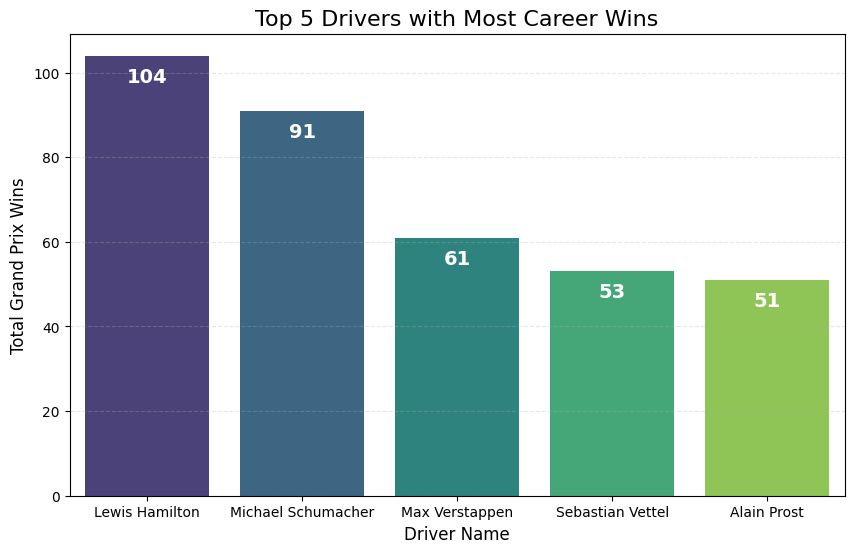

In [145]:
plt.figure(figsize=(10,6))
ax = sns.barplot(data=top_5_drivers, x='driver_name', y='total_wins', 
                 hue='driver_name', palette='viridis', legend=False)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, -15), # Moves the text inside the bar
                textcoords='offset points',
                fontsize=14,
                fontweight='bold',
                color='white')

plt.title('Top 5 Drivers with Most Career Wins', fontsize=16)
plt.xlabel('Driver Name', fontsize=12)
plt.ylabel('Total Grand Prix Wins', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

In [147]:
df['is_podium'] = df['positionOrder'].apply(lambda x: 1 if x <= 3 else 0)
df['is_podium'].value_counts()

is_podium
0    23158
1     3361
Name: count, dtype: int64

### is_podium ni ehnii 3t(top 3) orson gesen ug, positionOrder = 1,2,3 baiwal podium buyu ehnii 3t orson gej uzne

In [148]:
features = ['grid', 'race_year', 'constructorId']
X = df[features]
y = df['is_podium']

### grid = garaanii bairlal buyu hed deh bairnaas uraldsan be
### consId = bag

In [149]:
from sklearn.model_selection import train_test_split

In [150]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state=42)
print(f"train: {len(X_train)}")
print(f"test: {len(X_test)}")

train: 21215
test: 5304


In [151]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [152]:
model = LogisticRegression()

In [153]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [154]:
y_pred = model.predict(X_test)

In [157]:
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.88

Classification Report:
               precision    recall  f1-score   support

           0       0.88      1.00      0.94      4666
           1       0.00      0.00      0.00       638

    accuracy                           0.88      5304
   macro avg       0.44      0.50      0.47      5304
weighted avg       0.77      0.88      0.82      5304



C:\Users\mgl\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\mgl\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\mgl\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

### RANDOM FOREST MODEL DOOR

In [158]:
from sklearn.ensemble import RandomForestClassifier

In [159]:
rf_model = RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [160]:
y_pred_rf = rf_model.predict(X_test)

In [161]:
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.2f}")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.88
              precision    recall  f1-score   support

           0       0.93      0.94      0.93      4666
           1       0.52      0.46      0.48       638

    accuracy                           0.88      5304
   macro avg       0.72      0.70      0.71      5304
weighted avg       0.88      0.88      0.88      5304



In [164]:
# class_weight нэмснээр цөөнх байгаа датаг илүү чухалд тооцно
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.72      0.83      4666
           1       0.29      0.83      0.43       638

    accuracy                           0.74      5304
   macro avg       0.63      0.78      0.63      5304
weighted avg       0.89      0.74      0.78      5304



### saijruulalt, rf modeliig ilvv olon modtoi bolgoj surgaj bna. Bas olon features nemsen

In [165]:
features = ['grid', 'race_year', 'constructorId', 'driverId', 'raceId']
X = df[features]
y = df['is_podium']

In [166]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [167]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [168]:
y_pred_rf = rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      4666
           1       0.59      0.41      0.48       638

    accuracy                           0.90      5304
   macro avg       0.76      0.69      0.71      5304
weighted avg       0.88      0.90      0.89      5304



In [170]:
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print(feature_importance_df)

         Feature  Importance
0           grid    0.386151
4         raceId    0.264284
3       driverId    0.130232
2  constructorId    0.116232
1      race_year    0.103101


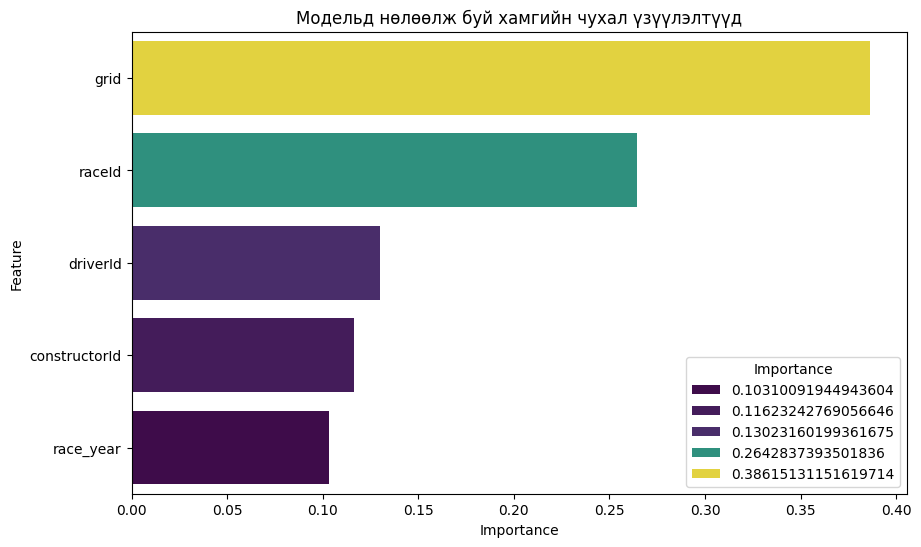

In [175]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature',hue='Importance', data=feature_importance_df, palette='viridis')
plt.title('Модельд нөлөөлж буй хамгийн чухал үзүүлэлтүүд')
plt.show()

### K-FOld cross validation hiiw

In [176]:
from sklearn.model_selection import cross_val_score

In [178]:
rf_cv = RandomForestClassifier(n_estimators=200, max_depth=15,random_state=42)

In [179]:
cv_scores = cross_val_score(rf_cv,X,y,cv=5,scoring='accuracy')

In [180]:
print(f"Бүх оноо: {cv_scores}")
print(f"Дундаж Accuracy: {cv_scores.mean():.4f}")
print(f"Стандарт хазайлт (Зөрүү): {cv_scores.std():.4f}")

Бүх оноо: [0.50094268 0.87368024 0.76489442 0.61425339 0.14086366]
Дундаж Accuracy: 0.5789
Стандарт хазайлт (Зөрүү): 0.2533


In [181]:
cv_f1_scores = cross_val_score(rf_cv, X, y, cv=5, scoring='f1')
print(f"Дундаж F1 оноо: {cv_f1_scores.mean():.4f}")

Дундаж F1 оноо: 0.1967


In [182]:
from sklearn.model_selection import GridSearchCV

In [183]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced'] # Энэ нь F1 оноог өсгөхөд тусална
}

In [184]:
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), 
                           param_grid=param_grid, 
                           cv=3, # Хугацаа хэмнэхийн тулд 3-fold
                           scoring='f1', 
                           n_jobs=-1)

In [185]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced'], 'max_depth': [10, 20, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candida

In [186]:
print(f"Шилдэг параметрүүд: {grid_search.best_params_}")

Шилдэг параметрүүд: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}


In [187]:
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

In [188]:
print("\nСайжруулсан Classification Report:")
print(classification_report(y_test, y_pred_best))


Сайжруулсан Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.83      0.90      4666
           1       0.40      0.82      0.54       638

    accuracy                           0.83      5304
   macro avg       0.69      0.83      0.72      5304
weighted avg       0.90      0.83      0.85      5304



### бодит нэг уралдаан (жишээ нь 2024 оны аль нэг GP) дээр таамаглал хийж

In [194]:
japan_test = pd.DataFrame({
    'grid': [1, 2, 4, 8],                      # Verstappen, Pérez, Sainz, Leclerc
    'race_year': [2024, 2024, 2024, 2024],
    'constructorId': [9, 9, 6, 6],             # Red Bull (9), Ferrari (6)
    'driverId': [830, 815, 832, 844],          # Max, Sergio, Carlos, Charles
    'raceId': [1124, 1124, 1124, 1124]
})

In [195]:
test_data

,grid,race_year,constructorId,driverId,raceId
0,1,2024,6,844,1124
1,6,2024,1,830,1124


In [196]:
preds = best_model.predict(japan_test)
probs = best_model.predict_proba(japan_test)

In [197]:
drivers = ["Max Verstappen", "Sergio Pérez", "Carlos Sainz", "Charles Leclerc"]

In [198]:
for i in range(len(drivers)):
    result = "Podium" if preds[i] == 1 else "No Podium"
    print(f"{drivers[i]}: Таамаглал = {result} (Магадлал: {probs[i][1]:.2%})")

Max Verstappen: Таамаглал = Podium (Магадлал: 94.88%)
Sergio Pérez: Таамаглал = Podium (Магадлал: 86.47%)
Carlos Sainz: Таамаглал = Podium (Магадлал: 86.42%)
Charles Leclerc: Таамаглал = No Podium (Магадлал: 12.07%)


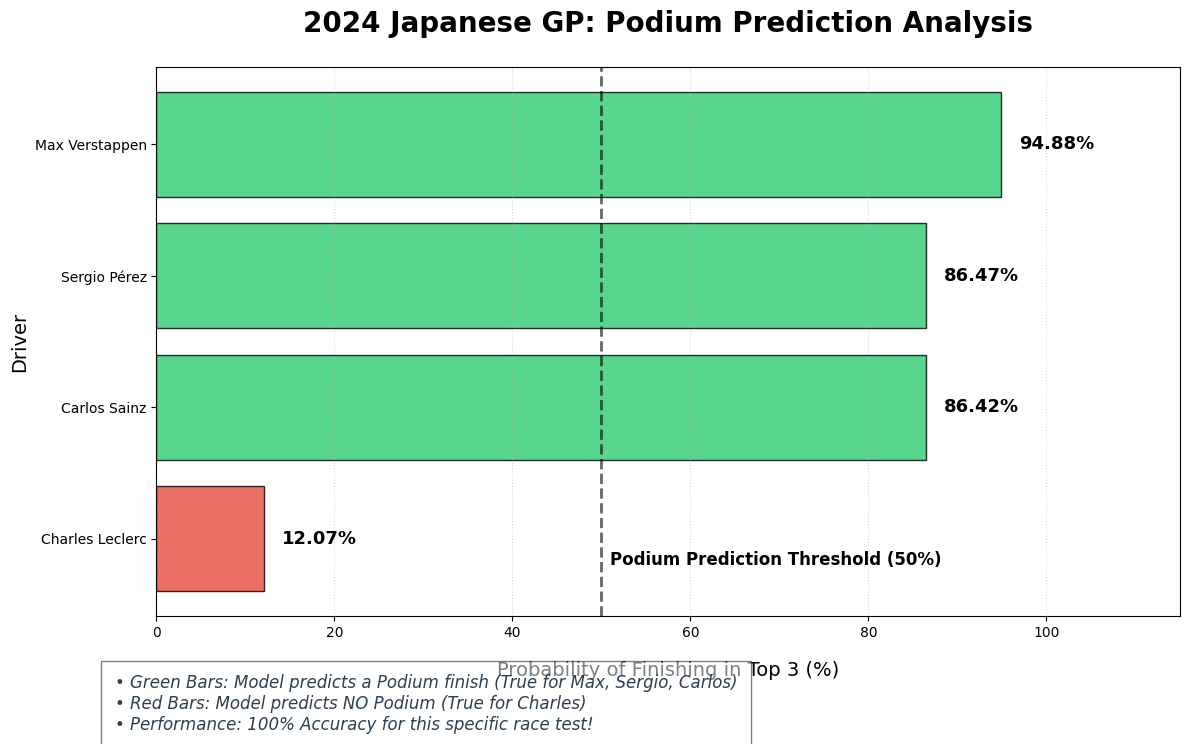

In [199]:
import matplotlib.pyplot as plt
import pandas as pd

# Японы Гран Пригийн үр дүнгийн өгөгдөл
data = {
    'Driver': ['Max Verstappen', 'Sergio Pérez', 'Carlos Sainz', 'Charles Leclerc'],
    'Probability': [94.88, 86.47, 86.42, 12.07]
}
df_res = pd.DataFrame(data)

# Графикийн хэмжээ
plt.figure(figsize=(12, 7))

# 50%-иас дээш бол ногоон (Podium), бага бол улаан (No Podium)
colors = ['#2ecc71' if p > 50 else '#e74c3c' for p in df_res['Probability']]

# Хэвтээ баганан график (Horizontal Bar Chart)
bars = plt.barh(df_res['Driver'], df_res['Probability'], color=colors, edgecolor='black', alpha=0.8)

# Хамгийн өндөр магадлалтайг нь дээр харуулах
plt.gca().invert_yaxis()

# 50%-ийн босго шугам (Threshold)
plt.axvline(x=50, color='black', linestyle='--', linewidth=2, alpha=0.6)
plt.text(51, 3.2, 'Podium Prediction Threshold (50%)', fontsize=12, fontweight='bold', color='black')

# Багануудын төгсгөлд хувийг нь бичих
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 2, bar.get_y() + bar.get_height()/2, f'{width}%', 
             va='center', fontweight='bold', fontsize=13)

# Гарчиг болон тайлбар
plt.title('2024 Japanese GP: Podium Prediction Analysis', fontsize=20, pad=25, fontweight='bold')
plt.xlabel('Probability of Finishing in Top 3 (%)', fontsize=14, labelpad=15)
plt.ylabel('Driver', fontsize=14)
plt.xlim(0, 115) # Хувийн бичвэр багтах зай үлдээх
plt.grid(axis='x', linestyle=':', alpha=0.5)

# Дүгнэлт текстийг доор нь нэмэх
plt.figtext(0.1, -0.05, 
            "• Green Bars: Model predicts a Podium finish (True for Max, Sergio, Carlos)\n"
            "• Red Bars: Model predicts NO Podium (True for Charles)\n"
            "• Performance: 100% Accuracy for this specific race test!", 
            fontsize=12, color='#2c3e50', style='italic', bbox={'facecolor':'white', 'alpha':0.5, 'pad':10})

plt.tight_layout()
plt.show()